# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [2]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

In [3]:
# Retornando os dados iniciais da base
base.head(15)

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0
5,60,1,151,67,2,2,0,0,0,0
6,61,1,157,93,3,1,0,0,1,0
7,62,2,178,95,3,3,0,0,1,1
8,48,1,158,71,1,1,0,0,1,0
9,54,1,164,68,1,1,0,0,0,0


In [4]:
# verificando informaçoes da base
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [5]:
# verificando dados unicos
# Agora que temos os Dtypes, vamos verificar os dados unicos que tem em cada coluna
colunas = base.columns
for i in colunas:

    print(f'Para a coluna {i}, temos os seguintes valores unicos {base[i].unique()}')
    print("=====================================")

Para a coluna age, temos os seguintes valores unicos [50 55 52 48 60 61 62 54 41 40 46 58 59 63 64 57 56 49 51 44 65 45 53 47
 42 39 43 30]
Para a coluna gender, temos os seguintes valores unicos [2 1]
Para a coluna height, temos os seguintes valores unicos [168 156 165 169 151 157 178 158 164 173 181 172 170 154 162 163 153 159
 166 155 160 175 171 152 187 148 179 180 188 185 167 183 174 176 161 184
 177 182  76 149 142 150 144 147 186 146 141 195 140 198 145 143 196 138
 194 190 134 136 100 120 189 137 192 122 250 191 117  70  97 119 130]
Para a coluna weight, temos os seguintes valores unicos ['62' '85' '64' '82' '56' '67' '93' '95' '71' '68' '80' '60' '78' '112'
 '75' '52' '83' '69' '90' '45' '65' '59' '66' '74' '105' '73' '55' '70'
 '72' '63' '50' '107' '84' '77' '79' '76' '58' '115' '97' '53' '57' '49'
 '110' '94' '92' '87' '103' '88' '99' '100' '61' '48' '54' '51' '47' '91'
 '104' '81' '98' '108' '89' '101' '86' '65,5' '142' '96' '44' '41' '169'
 '116' '200' '64,8' '120' '117' '

In [6]:
# Retornando estatisticas descritivas da base
base.describe()

,age,gender,height,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


**Tratamentos necessários**

Avaliando os dados da base de pacientes, podemos notar alguns itens que precisam ser tratados 

- **1 -  Coluna “weight”**

A coluna está como tipo object, ela armazena os dados de peso dos pacientes e será melhor aproveitada se tiver sido aplicado o tipo float e mudando o separador de virgula para ponto.
Outro ponto positivo com essa mudança é retornar dados estatísticos mais apurados com relação a esta variável pelo método describe().

- **2 - Coluna “height”**

Pelas estatísticas da coluna, podemos verificar que existem alguns outliers com relação aos valores máximos e mínimos, a altura mínima está em 70 e a máxima 250. Fazendo uma busca pela OMS e o percentual de pessoas que apresentam a condição de nanismo, foi encontrado que cerca de 0,004% da população mundial tem essa condição e que pela OMS consiste em pessoas em fase adulta que apresentam altura inferior a 1,45m para homens e 1,40m para mulheres existe um percentual muito grande na amostra de pessoas com essas condições, o que podemos deduzir que forma erros de digitação. 
Neste caso, vamos remover essas informações para evitar dados discrepantes que podem trazer erros no modelo futuro.
Fonte: https://www.tre-ce.jus.br/comunicacao/noticias/2022/Fevereiro/serie-vamos-falar-sobre-aborda-o-tema-nanismo
https://bvsms.saude.gov.br/nanismo/
https://diariopcd.com.br/nanismo-acomete-250-mil-pessoas-no-mundo-no-brasil-estima-se-que-seja-1-para-cada-10-mil-habitantes/

O mesmo será feito para dados com altura maior que 2,10m
 
- **3 - Coluna “cholesterol”**

A coluna cholesterol, não está relacionada no glossário de definição dos dados, mas avaliando a origem da relação dos dados(https://www.kaggle.com/datasets/mdshamimrahman/cardio-data-set/data) .Os valores significam:

1: Colesterol normal

2: Colesterol acima do normal

3: Colesterol muito acima do normal


#### 1 -  Coluna “weight

In [7]:
# Alterando o tipo da coluna weight

base['weight'] = base['weight'].str.replace(',', '.', regex=False).astype('float64')

# Validando mudança do tipo da coluna weight
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  int64  
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB


In [8]:
# trasendo metricas descritivas da coluna weight
base['weight'].describe()

count    10000.000000
mean        74.303710
std         14.566353
min         30.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64

#### 2 - Coluna "height"

In [9]:
# Antes de fazer a exclusão dos outliers, vamos analisar retornar os dados que serão excluidos

# Contando as linhas com altura menor que 145cm
linhas_menor_145 = base[base['height'] < 145]
count_menor_145 = len(linhas_menor_145)

# Contando as linhas com altura maior que 210cm
linhas_maior_210 = base[base['height'] > 210]
count_maior_210 = len(linhas_maior_210)

# total de linhas que serão excluidas
total_excluidas = count_menor_145 + count_maior_210

print(f"Número de linhas a serem removidas com 'height' menor que 145: {count_menor_145}")
print(f"Número de linhas a serem removidas com 'height' maior que 200: {count_maior_210}")
print(f"Total de linhas que serão removidas: {total_excluidas}, um percentual de {total_excluidas / len(base) * 100:.2f}% do total da base.")

Número de linhas a serem removidas com 'height' menor que 145: 46
Número de linhas a serem removidas com 'height' maior que 200: 1
Total de linhas que serão removidas: 47, um percentual de 0.47% do total da base.


In [10]:
# Removendo linhas com 'height' menor que 145 ou maior que 200
base_tratada = base[(base['height'] >= 145) & (base['height'] <= 210)]

# Exibindo o número de linhas antes e depois da filtragem para ver a diferença
print(f"Número de linhas antes: {len(base)}")
print(f"Número de linhas depois: {len(base_tratada)}")

Número de linhas antes: 10000
Número de linhas depois: 9953


In [11]:
# Avaliando os dados da base tratada
base_tratada.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,9953.000000,9953.000000,9953.000000,9953.000000,9953.000000,9953.000000,9953.000000,9953.000000,9953.000000,9953.000000
mean,53.288355,1.346026,164.450618,74.328655,1.365116,1.222445,0.089219,0.053954,0.796644,0.503064
std,6.792104,0.475726,7.754731,14.496103,0.677733,0.565940,0.285074,0.225937,0.402515,0.500016
min,30.000000,1.000000,145.000000,37.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,198.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
base_tratada.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9953 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             9953 non-null   int64  
 1   gender          9953 non-null   int64  
 2   height          9953 non-null   int64  
 3   weight          9953 non-null   float64
 4   cholesterol     9953 non-null   int64  
 5   gluc            9953 non-null   int64  
 6   smoke           9953 non-null   int64  
 7   alco            9953 non-null   int64  
 8   active          9953 non-null   int64  
 9   cardio_disease  9953 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 855.3 KB


# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


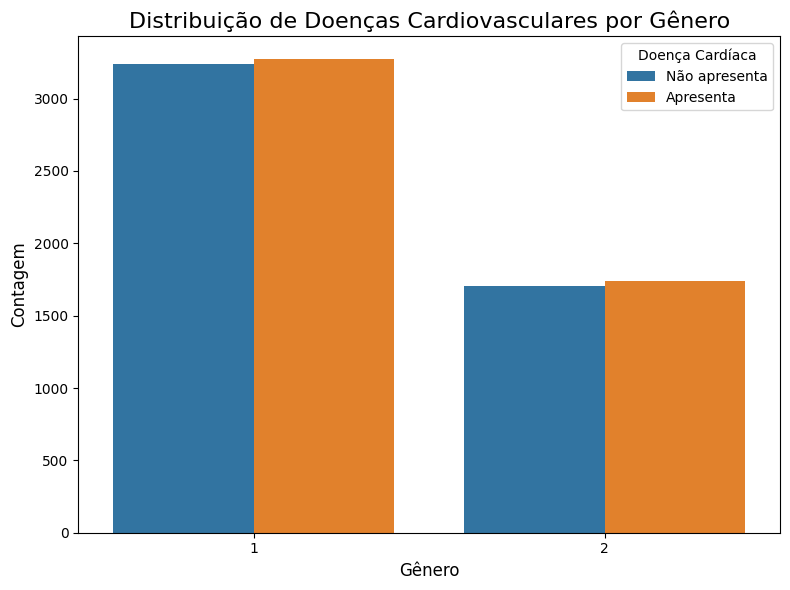

In [13]:
# Criando um gráfico de barras para visualizar a distribuição de doenças cardiovasculares por sexo
# Criando o gráfico de barras
plt.figure(figsize=(8, 6))
sns.countplot(data=base_tratada, x='gender', hue='cardio_disease')

# Configurando títulos e rótulos
plt.title('Distribuição de Doenças Cardiovasculares por Gênero', fontsize=16)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Contagem', fontsize=12)

# Adicionando uma legenda mais clara
plt.legend(title='Doença Cardíaca', labels=['Não apresenta', 'Apresenta'])

# Ajustando o layout
plt.tight_layout()

plt.show()


**Insights sobre Distribuição de Doenças Cardiovasculares por Gênero**
- Podemos visualizar que o gênero 1 (Masculino) tem a maior representatividade dos dados da amostra de pacientes.

- Mesmo apresentando proporção numérica diferente, em ambos os gêneros, a quantidade de pessoas com e sem doenças cardiovasculares é igual. Isso sugere que a prevalência da doença não varia de forma significativa em função do género.

- Por ter uma distribuição equilibrada entre os dados, o fator de gênero não está vincula uma característica relevante para a inferência de doenças cardiovasculares


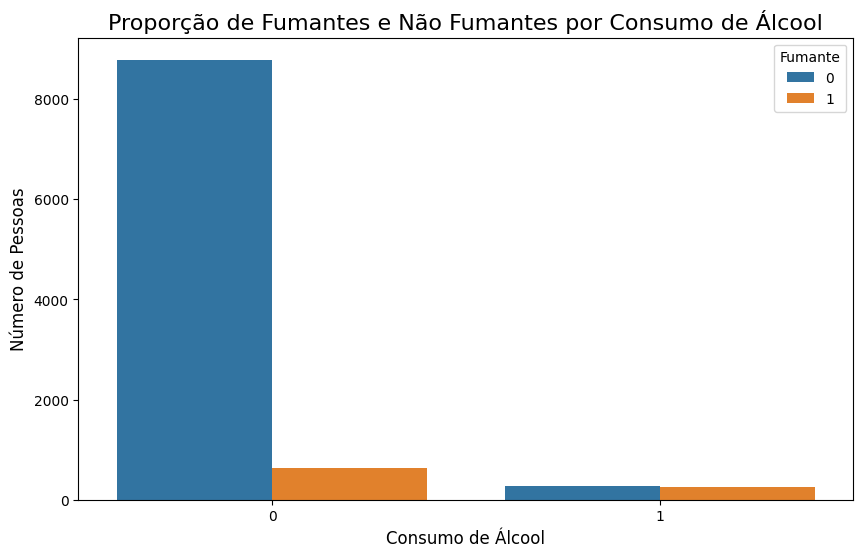

In [14]:
# Criando um gráfico de barras para avaloar a relação entre pessoas que fumam e ingerem álcool
# Criando um gráfico de barras agrupado para mostrar a relação entre as variáveis
plt.figure(figsize=(10, 6))

# Usando countplot do Seaborn para facilitar a visualização
# O parâmetro 'hue' agrupa as barras de acordo com a variável 'fumante'
sns.countplot(x='alco', hue='smoke', data=base_tratada)

# Configurando os títulos e rótulos
plt.title('Proporção de Fumantes e Não Fumantes por Consumo de Álcool', fontsize=16)
plt.xlabel('Consumo de Álcool', fontsize=12)
plt.ylabel('Número de Pessoas', fontsize=12)

# Melhorando a legenda
plt.legend(title='Fumante', loc='upper right')

# Exibindo o gráfico
plt.show()

**Proporção de Fumantes e Não Fumantes por Consumo de Álcool**

- Entre os que não consomem  álcool, o número de não fumantes é muito significativo, sugerindo que a ausência de hábitos de risco podem estar relacionados à ausência neste grupo.

- Por outro lado, pessoas que consomem álcool parecem ter maior propensão ao tabagismo. Isso pode indicar um padrão de comportamento associado a hábitos de risco

- O número total de pessoas que consomem álcool é bem menor que o grupo que não consome. Isso pode indicar uma baixa prevalência de consumo de álcool na amostra ou uma possível sub-representação.

- Avaliando os dados, não podemos afirmar de forma objetiva que a respostas sobre o consumo de álcool sejam verossímeis. Seria mais adequado realizar uma pergunta sobre a quantidade de bebida alcoólica ingerida para refletir dados mais apurados sobre a relação entre tabagismo e consumo de álcool, com também uma possível correlação entre a variável e problemas cardíacos 


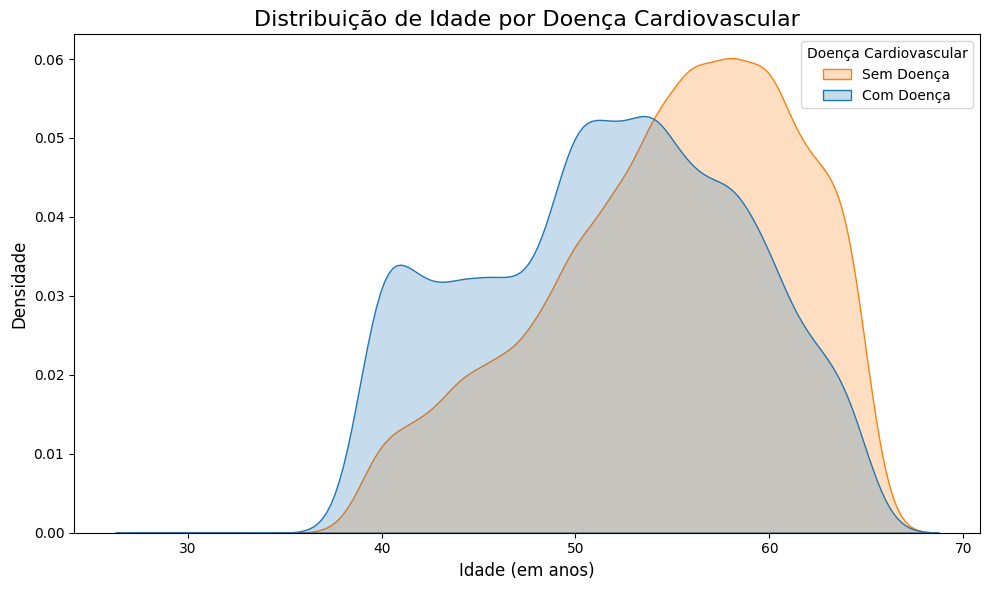

In [15]:
# Analisando a distribuição de idade por doença cardiovascular
# Criando um gráfico de densidade
plt.figure(figsize=(10, 6))
sns.kdeplot(data=base_tratada, x='age', hue='cardio_disease', common_norm=False, fill=True)

# Mapeando os rótulos da legenda para nomes mais claros
plt.legend(title='Doença Cardiovascular', labels=['Sem Doença', 'Com Doença'])

# Configurando títulos e rótulos
plt.title('Distribuição de Idade por Doença Cardiovascular', fontsize=16)
plt.xlabel('Idade (em anos)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)

plt.tight_layout()
plt.show()

**Insights sobre Distribuição de Idade por Doença Cardiovascularero**
- O gráfico mostra claramente que a idade é um fator de risco significativo para o desenvolvimento de doenças cardiovasculares. A probabilidade de uma pessoa ter a doença aumenta com o envelhecimento.

- A distribuição de idade do grupo "Com Doença" é mais ampla, o que significa que, embora o risco seja maior em idades mais avançadas, a doença também pode afetar pessoas mais jovens, embora em menor proporção.

- A análise visual do gráfico reforça a ideia de que a idade é um dos principais fatores de risco, com a incidência de doenças cardiovasculares se tornando mais prevalente à medida que as pessoas envelhecem.


# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



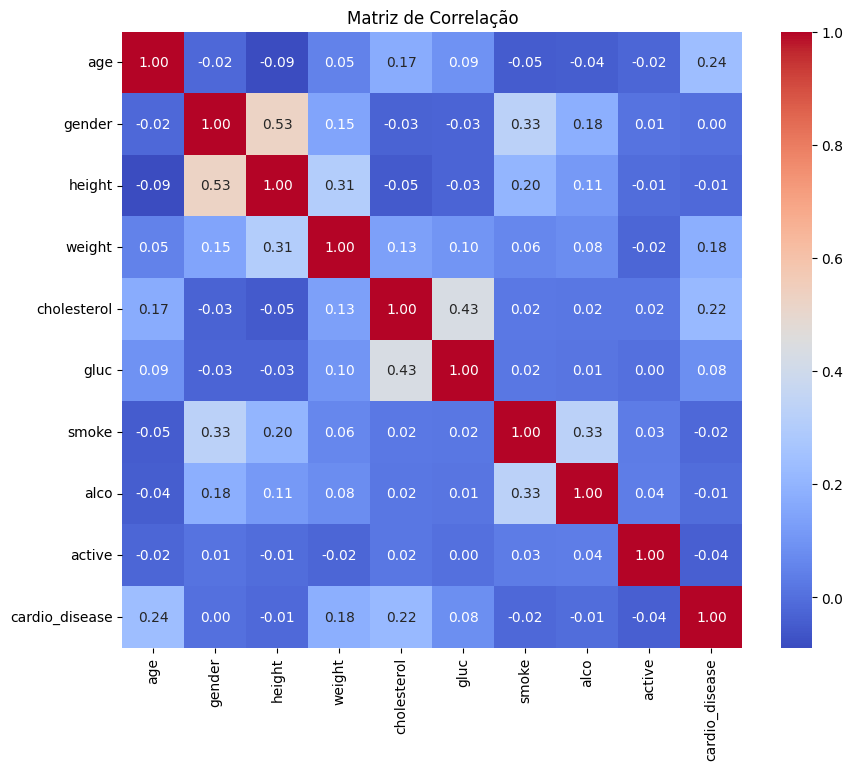

In [16]:
# seu código aqui
# Criando um mapa de calor para visualizar a matriz de correlação

correlation_matrix = base_tratada.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

- A idade apresenta a correlação mais forte e positiva com a ocorrência de doenças cardiovasculares. Isso reforça a observação feita anteriormente: o risco de desenvolver esse tipo de doença aumenta consideravelmente com o avanço da idade. 

- Existe uma correlação positiva moderada entre peso e doença cardiovascular. Embora não tão expressiva quanto a idade, esse dado sugere que o peso pode atuar como um fator de risco — pessoas com maior peso tendem a ter maior probabilidade de desenvolver a condição.

- A correlação entre gênero e doença cardiovascular é praticamente inexistente. Isso indica que, segundo os dados analisados, o gênero não influencia significativamente a incidência da doença.

- A correlação é negativa, porém muito fraca. Ainda que discreta, essa tendência sugere que indivíduos fisicamente ativos têm uma chance ligeiramente menor de apresentar doenças cardiovasculares.

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [17]:
# Separando os dados em variáveis independentes (x) e dependente (y)
X = base_tratada.drop('cardio_disease', axis=1)
y = base_tratada['cardio_disease']

In [18]:
# Separando os dados em conjuntos de trino e teste
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42)

In [19]:
print("Tamanho de X_train:", X_train.shape)
print("Tamanho de X_test:", X_test.shape)
print("Tamanho de y_train:", y_train.shape)
print("Tamanho de y_test:", y_test.shape)

Tamanho de X_train: (7464, 9)
Tamanho de X_test: (2489, 9)
Tamanho de y_train: (7464,)
Tamanho de y_test: (2489,)


**Sobre a questão de padronização**

Para o modelo de regressão Logística, **é fundamental que exista a padronização de dados**. A regressão Logística é um algoritmo que funciona bem com variáveis que têm a mesma escala. quando as variáveis têm uma escala muito diferente, podem acabar dominando o cálculo dos coeficientes do modelo. Isso pode levar ao modelo viés que não reflete a real relevância de cada variável.

podemos elencar as variáveis  que mais apresentam variações em seus valores, são elas 

- Idade (age)
- Peso (weight)
- Altura (height)
- Colesterol (cholesterol)

In [20]:
# Iniciando o processo de padronização da base com StandardScaler
scaler = StandardScaler()

# Ajustando a baase de treino
X_train = scaler.fit_transform(X_train)

# Transformadno a base de teste usando os parâmetros da base de treino
X_test = scaler.transform(X_test)

In [21]:
# Avaliando se as bases de treino e teste estão balanceadas
balanceamento_train_y = y_train.value_counts(normalize=True)
proporcao_treino_Y = y_train.value_counts(normalize=True) * 100

print("Contagem das classes (Treino):")
print(balanceamento_train_y)
print("\nProporção das classes (Treino):")
print(proporcao_treino_Y)

Contagem das classes (Treino):
cardio_disease
1    0.505895
0    0.494105
Name: proportion, dtype: float64

Proporção das classes (Treino):
cardio_disease
1    50.589496
0    49.410504
Name: proportion, dtype: float64


**Avaliação**

Por apresentar uma proporção muito próxima dos dados de cardio_disease entre 0 e 1, não julgo necessario realizar nenhum tipo de balanceamento na base de treino.

In [22]:
# visualizando os dados da base de trino e teste 
print("X_train:\n", X_train)
print("X_test:\n", X_test)
print("y_train:\n", y_train)
print("y_test:\n", y_test)

X_train:
 [[ 0.2470901  -0.73025924 -0.32508107 ... -0.31454718 -0.23416498
   0.5109049 ]
 [ 1.5723216   1.36937672 -0.32508107 ...  3.1791733   4.27049334
   0.5109049 ]
 [ 1.5723216  -0.73025924  0.44983938 ... -0.31454718 -0.23416498
  -1.95731141]
 ...
 [ 0.2470901  -0.73025924  0.44983938 ... -0.31454718 -0.23416498
   0.5109049 ]
 [-0.34190168 -0.73025924 -0.06677425 ...  3.1791733  -0.23416498
   0.5109049 ]
 [ 0.98332982 -0.73025924  0.83729961 ... -0.31454718 -0.23416498
   0.5109049 ]]
X_test:
 [[-0.78364551  1.36937672  1.99968029 ... -0.31454718 -0.23416498
  -1.95731141]
 [ 0.39433804  1.36937672 -0.06677425 ... -0.31454718 -0.23416498
   0.5109049 ]
 [-1.37263729  1.36937672  1.09560643 ... -0.31454718 -0.23416498
   0.5109049 ]
 ...
 [-0.19465373 -0.73025924  0.44983938 ... -0.31454718 -0.23416498
   0.5109049 ]
 [ 0.09984216  1.36937672  0.19153257 ... -0.31454718 -0.23416498
   0.5109049 ]
 [-0.48914962  1.36937672 -0.19592766 ... -0.31454718 -0.23416498
   0.5109049 

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [23]:
# Encontrando os coeficientes do modelo de regressão logistica
log_reg_cardio = LogisticRegression(random_state=0)

# Treinando o modelo de regressão logística
log_reg_cardio.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [24]:
# retornando o intercept e os coeficientes
log_reg_cardio.intercept_

array([0.04211345])

In [25]:
log_reg_cardio.coef_

array([[ 0.43536869,  0.03679927, -0.08453722,  0.36816615,  0.44238154,
        -0.09512154, -0.05135   , -0.01317717, -0.08959553]])

In [26]:
# Realizando previsões com o modelo treinado
prev_test = log_reg_cardio.predict(X_train)

In [27]:
# gerando relatório de classificação
report = classification_report(y_train, prev_test)
print("Relatório de Classificação:")
print(report)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.63      0.66      0.64      3688
           1       0.65      0.62      0.64      3776

    accuracy                           0.64      7464
   macro avg       0.64      0.64      0.64      7464
weighted avg       0.64      0.64      0.64      7464



**Avaliação do Relatório de Classificação dos dados de Treino**
- Precisão (Precision):
    - Classe 0 (Sem doença): A precisão de 0.63 significa que, de todas as vezes que o modelo previu que um paciente não tinha a doença, ele estava correto em 63% dos casos.

    - Classe 1 (Com doença): A precisão de 0.65 significa que, de todas as vezes que o modelo previu que um paciente tinha a doença, ele estava correto em 65% dos casos.

- Recall (Sensibilidade):

    - Classe 0 (Sem doença): O recall de 0.66 indica que o modelo identificou corretamente 66% de todos os pacientes que realmente não tinham a doença.

    - Classe 1 (Com doença): O recall de 0.62 indica que o modelo identificou corretamente 62% de todos os pacientes que realmente tinham a doença.

- F1-Score: O F1-Score é uma média harmônica da precisão e do recall, útil para ter uma visão geral do desempenho do modelo em uma única métrica.

    - Classe 0 e 1: Os valores de F1-Score de 0.64 para ambas as classes sugerem que o modelo tem um desempenho equilibrado, mas moderado, na identificação de pacientes com e sem a doença.

- Suporte (Support):
O suporte mostra o número de ocorrências de cada classe na base de dados de teste.

- Classe 0: Havia 3688 pacientes sem a doença.

- Classe 1: Havia 3776 pacientes com a doença.

Os resultados indicam um desempenho geral moderado. A acurácia de 0.64 (64%) significa que o modelo acertou a previsão para cerca de 64% dos pacientes.

Para um problema tão crítico como a detecção de doenças cardíacas, a precisão e o recall de cerca de 64% podem não ser aceitaveis tratando-se de questões de saúde.

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [28]:
# Aplicando o modelo na base de teste
prev_test_final = log_reg_cardio.predict(X_test)

In [29]:
# Gerando relatório de classificação
report = classification_report(y_test, prev_test_final)
print("Relatório de Classificação:")
print(report)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.63      0.66      0.65      1258
           1       0.64      0.61      0.62      1231

    accuracy                           0.64      2489
   macro avg       0.64      0.63      0.63      2489
weighted avg       0.64      0.64      0.63      2489



**Avaliação do Relatório de Classificação dos dados de Teste**

Os resultados são muito semelhantes aos do relatório de classificação da base de treino anterior. A acurácia geral do modelo na base de teste é de 0.64, o que é consistente.


- Precisão (Precision):

    - Classe 0 (Sem doença): A precisão de 0.63 indica que 63% das previsões do modelo para a classe 0 estavam corretas.

    - Classe 1 (Com doença): A precisão de 0.64 mostra que 64% das previsões do modelo para a classe 1 estavam corretas.

- Recall (Sensibilidade):

    - Classe 0 (Sem doença): O recall de 0.66 significa que o modelo identificou corretamente 66% dos pacientes que realmente não tinham a doença.

    - Classe 1 (Com doença): O recall de 0.61 indica que o modelo identificou corretamente 61% dos pacientes que realmente tinham a doença.

- F1-Score:

    - O F1-Score para a Classe 0 é de 0.65 e para a Classe 1 é de 0.62. Esses valores sugerem que o modelo tem um desempenho equilibrado, mas ainda assim moderado, na classificação.

- Suporte (Support):

    - Classe 0: Havia 1258 pacientes sem a doença na base de teste.

    - Classe 1: Havia 1231 pacientes com a doença na base de teste.



In [31]:
fpr, tpr, thresholds = roc_curve(y_test, prev_test_final)

# Calcular a AUC
roc_auc = roc_auc_score(y_test, prev_test_final)
print("AUC: {:.2f}".format(roc_auc))

AUC: 0.63


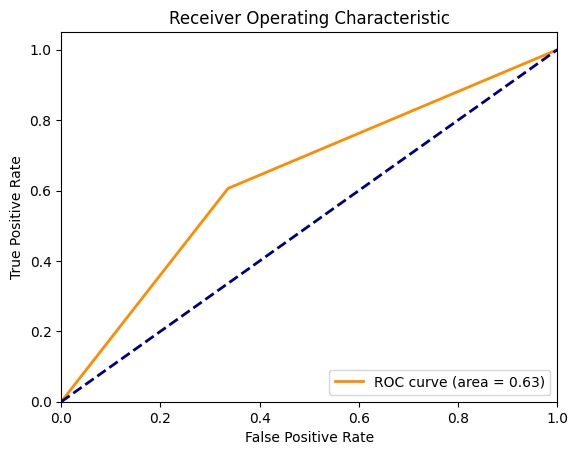

In [32]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

**Análise do gráfico ROC**

A análise da curva ROC confirma o que os relatórios de classificação já indicavam, o modelo tem um desempenho modesto, tendo como referência o AUC(Area under the Curve) estar entre 0.5 e 0.7. Para um problema crítico como a detecção de doenças cardíacas, o ideal seria ter uma AUC próxima de 1, para garantir maior credibilidade nas previsões e minimizar o risco de diagnósticos incorretos.

Ou seja, ele não está apresentando boas indicações de confirmação de doenças cardíacas, está dando um chute sobre uma determinada condição de paciente.

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



Respondendo todas as questões 

A regressão logística é um algoritmo de aprendizagem de máquina (machine learning) usado para resolver problemas de classificação. Apesar de ter a palavra "regressão" no nome, seu objetivo principal é prever a probabilidade de uma determinada amostra pertencer a uma das classes (por exemplo, "sim" ou "não", "doente" ou "saudável", "spam" ou "não-spam").

O modelo funciona de maneira similar a uma regressão linear, mas usa uma função especial chamada função sigmoide (ou "função logística") para converter o resultado linear em uma probabilidade.

Em comum com a regressão linear, ambos os modelos utilizam equação linear para descrever a relaçào entre as variáveis independentes e uma variaval dependente. Ambos os modelos têm o objetivo de encontrar os melhores valores para os coeficientes que minimizem o erro das previsões e assumem que existe uma relação linear entre as variáveis de entrada e a saída (ou uma versão transformada da saída, no caso da regressão logística).